# Web App Testing with TinyTroupe

This notebook demonstrates how to use TinyTroupe agents to interact with **real web browsers** via the `TinyWebBrowserFaculty`.
This enables use cases such as:

- **Software testing** — agents simulate real users navigating web applications
- **Manual work automation** — agents perform repetitive web tasks
- **User experience research** — observe how simulated personas interact with web interfaces

The faculty uses [Playwright](https://playwright.dev/python/) under the hood, and supports:
- Both high-level natural-language commands (`BROWSE`) and low-level atomic actions (`BROWSE_ACTION`)
- Multiple authentication strategies (persistent Edge profile, manual login, credential injection)
- Multi-tab browsing with persistent sessions
- User intervention at any point via direct faculty methods

> **Jupyter compatibility:** Playwright's sync API normally conflicts with Jupyter's asyncio event
> loop. `BrowserController` detects this automatically and dispatches all Playwright operations to
> a dedicated background thread — no extra setup is needed.

## Prerequisites

```bash
pip install tinytroupe[browser]
playwright install msedge  # or: playwright install chromium
```

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import tinytroupe
from tinytroupe.agent import TinyPerson
from tinytroupe.agent.web_browser_faculty import TinyWebBrowserFaculty
from tinytroupe.environment import TinyWorld
from tinytroupe.examples import create_oscar_the_architect
from IPython.display import Image, display


!!!!
DISCLAIMER: TinyTroupe relies on Artificial Intelligence (AI) models to generate content. 
The AI models are not perfect and may produce inappropriate or inacurate results. 
For any serious or consequential use, please review the generated content before using it.
!!!!

Looking for default config on: c:\Users\pdasilva\repos\TinyTroupe\examples\..\tinytroupe\utils\..\config.ini
Found custom config on: c:\Users\pdasilva\repos\TinyTroupe\examples\config.ini
TinyTroupe version: 0.6.0
Current date and time (local): 2026-02-13 22:42:08
Current date and time (UTC):   2026-02-14 01:42:08

Current TinyTroupe configuration 
[OpenAI]
api_type = openai
azure_api_version = 2024-08-01-preview
model = gpt-5-mini
reasoning_model = o3-mini
vision_detail = auto
embedding_model = text-embedding-3-small
azure_embedding_model_api_version = 2023-05-15
max_completion_tokens = 128000
timeout = 480
max_attempts = 5
waiting_time = 0
exponential_backoff_factor = 5
max_concurrent_model_calls = 4
reasoning_e

## 2. Create an Agent with Web Browsing Capability

We load a pre-defined agent (Oscar, a seasoned architect) and equip it with the `TinyWebBrowserFaculty`.
By default, the browser uses **Microsoft Edge** in **headed** mode (visible window), so you can watch and intervene.

We also set `max_content_length=2000` to keep page content concise — this prevents the embedding
model's token limit (8192) from being exceeded during memory consolidation.

In [2]:
# Create the agent from a pre-defined example specification
oscar = create_oscar_the_architect()

# Add the web browser faculty.
# use_vision=False skips the expensive LLM vision call per step (~10 s
# saved each time) — the agent still receives the page's accessibility
# tree, which is sufficient for reading and navigating.
# max_content_length: 5000 chars lets the accessibility tree include
# recipe-level detail (ingredients, steps) beyond nav boilerplate,
# while still staying safely under the embedding model's 8192-token limit.
browser_faculty = TinyWebBrowserFaculty(
    headless=False,              # visible browser window
    max_content_length=5000,     # capture recipe details in a11y tree
    use_vision=False,            # fast mode — skip LLM screenshot description
)

oscar.add_mental_faculty(browser_faculty)
print(f"Agent '{oscar.name}' is ready with web browsing capability.")

Agent 'Oscar' is ready with web browsing capability.


## 3. Direct User Navigation

Before letting the agent loose, the **user** (you!) can navigate the browser directly using the faculty's `user_*` methods.
These bypass the agent's cognitive loop — the agent will observe the resulting state on its next browser action.

In [3]:
# Navigate to a website
result = browser_faculty.user_goto("https://example.com")
print(f"Navigation result: {result}")

Navigation result: {'success': True, 'url': 'https://example.com/', 'title': 'Example Domain'}


Screenshot saved to: C:\Users\pdasilva\AppData\Local\Temp\tinytroupe_browser_1771033422762.png


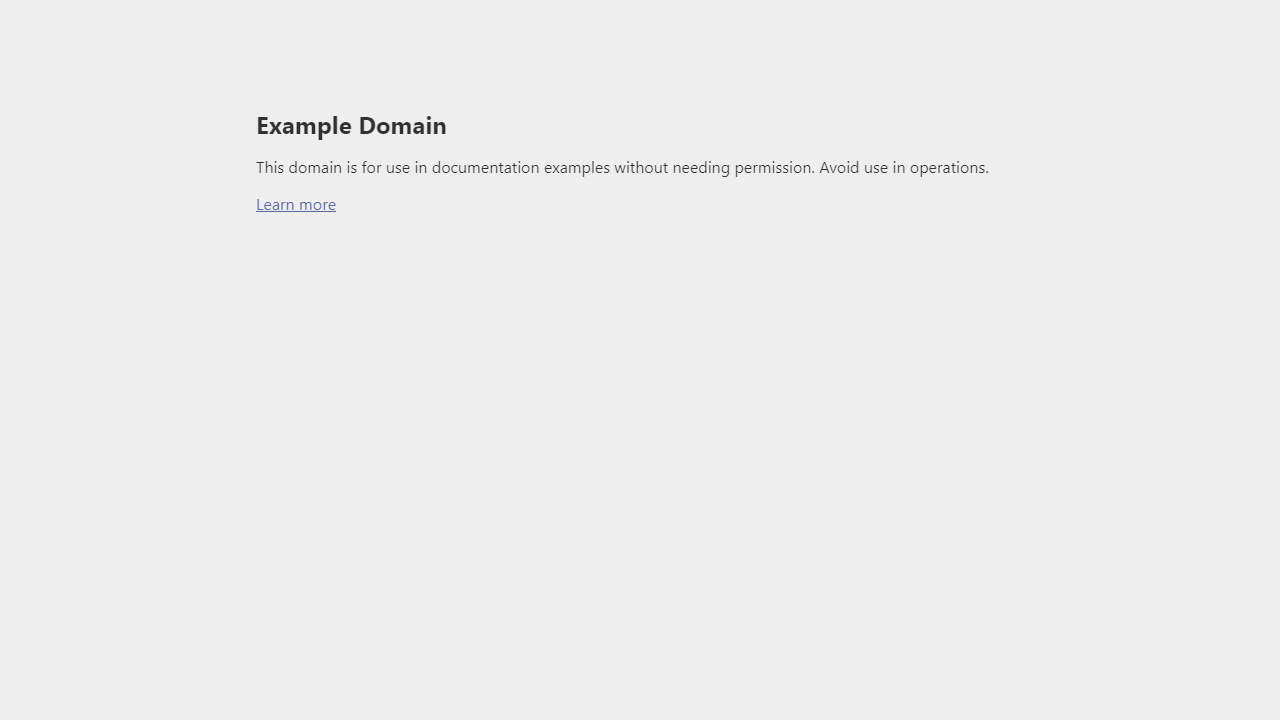

In [4]:
# Take a screenshot
screenshot_path = browser_faculty.user_screenshot()
print(f"Screenshot saved to: {screenshot_path}")

# Display the screenshot inline
import os
from IPython.display import Image, display
if screenshot_path and os.path.isfile(screenshot_path):
    display(Image(filename=screenshot_path, width=600))
else:
    print(f"Screenshot not available (path: {screenshot_path})")

In [5]:
# Get the page content (using the configured strategy — accessibility tree by default)
content = browser_faculty.user_get_page_content()
print(content[:500])

WebArea "Example Domain"
  heading "Example Domain"
  text "This domain is for use in documentation examples without needing permission. Avoid use in operations."
  [0] link "Learn more"


## 4. Autonomous Recipe Browsing

Now let's see Oscar's browsing capabilities in a realistic scenario. Oscar is very hungry
and wants a cold Spanish gazpacho — a perfect dish for a hot day.

The workflow mirrors real-world agent usage:

1. The **user** navigates to Bing and submits a search query (demonstrating search interaction)
2. The **user** opens AllRecipes search results (a Cloudflare-free site with simpler DOM)
3. **Oscar** autonomously browses the results, randomly picks one that catches his eye, clicks it, and reads the full recipe page
4. **Oscar** shares his opinion on the recipe — would he cook it tonight?

We use a **two-phase** approach with `TinyWorld`:
- **Phase 1 (browsing + reading):** The agent scrolls the search results, picks a recipe, navigates to it, and reads the page (~6 steps)
- **Phase 2 (reporting):** The agent shares its opinion based on what it actually read (~3 steps)

> **Note:** We handle initial navigation as user interventions, while the agent handles
> the *cognitive* parts: choosing, clicking, reading, understanding, and forming an opinion.
> The `BrowserController` applies stealth measures (suppressing `navigator.webdriver`) to
> avoid bot-detection.

Navigation to Bing: OK
No cookie dialog (or already dismissed).
Search submitted.


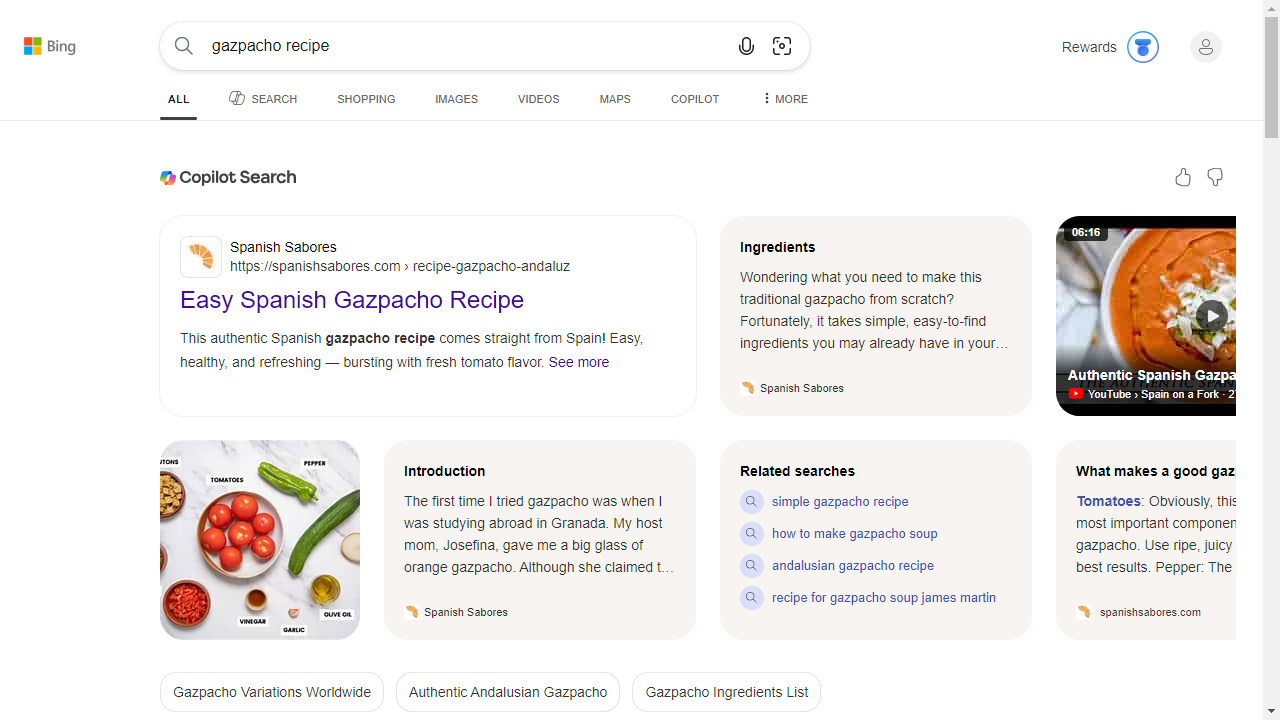

In [6]:
# Give Oscar some situational context — he's starving!
oscar.change_context([
    "You are very hungry right now and craving a cold Spanish gazpacho.",
    "You want to find a good traditional recipe online.",
])

# ── User interventions ──────────────────────────────────────────────
# These are the "mechanical" steps a user would do before handing off
# to the agent.  Think of them like opening a browser, typing a URL,
# and scrolling to a page.

import time

# 1. Navigate to Bing and search for a recipe
result = browser_faculty.user_goto("https://www.bing.com")
print(f"Navigation to Bing: {'OK' if result['success'] else 'FAILED'}")

# 2. Dismiss the cookie-consent dialog (Bing's Accept is an <a>, not a <button>)
time.sleep(2)
ctrl = browser_faculty._get_browser_controller()
cookie_result = ctrl.click("a:has-text('Accept')")
if cookie_result["success"]:
    time.sleep(1)
    print("Cookie dialog dismissed.")
else:
    print("No cookie dialog (or already dismissed).")

# 3. Search for "gazpacho recipe"
ctrl.fill("#sb_form_q", "gazpacho recipe")
time.sleep(0.5)
ctrl.press("Enter")
time.sleep(3)
print("Search submitted.")

# Show the search results
screenshot_path = browser_faculty.user_screenshot()
display(Image(filename=screenshot_path, width=800))

Navigated to AllRecipes search: OK
Page title: [gazpacho] Results from Allrecipes


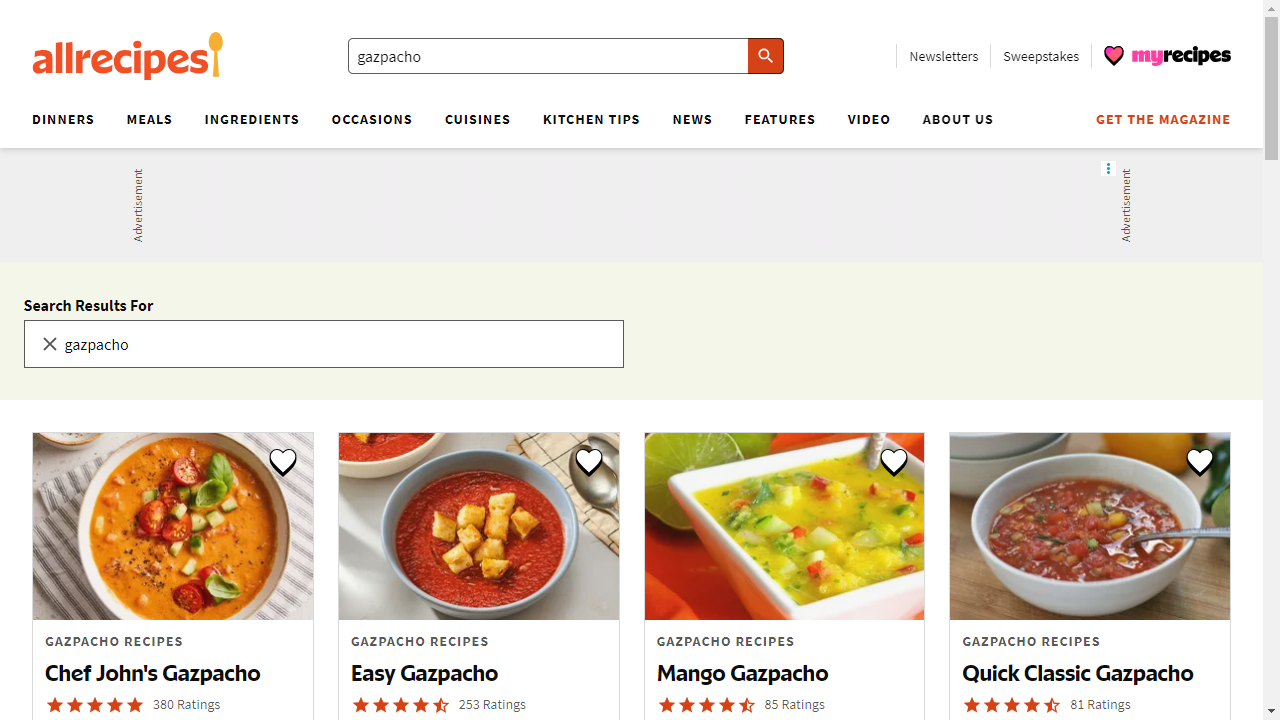

In [7]:
# 4. Navigate to a detailed recipe page.
#    We use AllRecipes' search results to find a specific gazpacho recipe.
#    AllRecipes is not blocked by Cloudflare, so links will load reliably.
import os

# Use AllRecipes' search for gazpacho
recipe_url = "https://www.allrecipes.com/search?q=gazpacho"
result = browser_faculty.user_goto(recipe_url)
time.sleep(4)
print(f"Navigated to AllRecipes search: {'OK' if result['success'] else 'FAILED'}")
print(f"Page title: {result.get('title', 'N/A')}")

screenshot_path = browser_faculty.user_screenshot()
if screenshot_path and os.path.isfile(screenshot_path):
    display(Image(filename=screenshot_path, width=800))
else:
    print(f"Screenshot not available (path: {screenshot_path})")

In [8]:
# Phase 1 — Autonomous browsing + reading (6 steps)
# Oscar is already on AllRecipes' gazpacho search results (navigated in the
# previous cell).  We feed him the current page state first so he can SEE
# the results and interact with them directly — no need to re-navigate.
world = TinyWorld("Recipe Browsing", [oscar])

# Feed Oscar the current browser state so he knows exactly where he is
browser_faculty._feed_observation(
    oscar,
    "Page already loaded: AllRecipes gazpacho search results",
    {
        "screenshot": ctrl.screenshot(),
        "page_content": ctrl.get_page_content(),
        "metadata": ctrl.get_page_metadata(),
    },
)

world.broadcast(
    "Your browser is ALREADY showing AllRecipes.com search results for "
    "'gazpacho'. You can see the recipe links in your last browser "
    "observation — do NOT navigate to any new URL.\n"
    "Your task:\n"
    "1. Use BROWSE_ACTION scroll down 500 to see more results.\n"
    "2. Look at the recipe links in your browser observation and pick "
    "one that catches your eye — do NOT always pick the first one; "
    "choose whichever looks most interesting to you.\n"
    "3. Use BROWSE_ACTION click to click that recipe's link.\n"
    "4. Once on the recipe page, use BROWSE_ACTION scroll down 500 to "
    "see the full recipe — ingredients, quantities, preparation "
    "steps, tips.\n"
    "5. Do NOT talk yet — just focus on browsing, clicking, and reading.\n"
    "IMPORTANT: Use BROWSE_ACTION commands (scroll, click) to interact "
    "with the page. Do NOT use BROWSE with long instructions."
)

# NOTE: parallelize=False is required — Playwright's sync API is single-threaded.
browsing_actions = world.run(6, return_actions=True, parallelize=False) or []

USER --> Oscar: [VISUAL] 
          > Current browser state after: Page already loaded: AllRecipes gazpacho search results

USER --> Oscar: [BROWSER_OBSERVATION] 
          > **Browser observation** after: Page already loaded: AllRecipes gazpacho search results
          > **URL:** https://www.allrecipes.com/search?q=gazpacho **Title:**  Results from
          > Allrecipes **Open tabs (1):** [0]  Results from Allrecipes  **Page content:**
          > ``` WebArea " Results from Allrecipes"   [0] link "SKIP TO CONTENT"   [1] link
          > "Visit Allrecipes' homepage"   text "Search the site"   [2] textbox "Search the site"
          > value="gazpacho"   [3] button "Click to search"   [4] button "Newsletters"   [5] link
          > "Sweepstakes"   [6] link "Go to MyRecipes"   [7] button "Close menu for Allrecipes"
          > [8] link "Visit Allrecipes' homepage"   text "Search"   [9] textbox "Search"
          > value="gazpacho"   [10] button "Click to search"   [11] link "DINNERS"   [12] link
          > "MEALS"   [13] link "INGREDIENTS"   [14] link "OCCASIONS"   [15] link "CUISINES"   [16]
          > link "KITCHEN TIPS"   [17] link "NEWS"   [18] link "FEATURES"   [19] link "VIDEO"   [20]
          > link "ABOUT US"   [21] link "GET THE MAGAZINE"   [22] link "Log In to Allre (...)

USER --> Oscar: [CONVERSATION] 
          > Your browser is ALREADY showing AllRecipes.com search results for 'gazpacho'. You can
          > see the recipe links in your last browser observation — do NOT navigate to any new URL.
          > Your task: 1. Use BROWSE_ACTION scroll down 500 to see more results. 2. Look at the
          > recipe links in your browser observation and pick one that catches your eye — do NOT
          > always pick the first one; choose whichever looks most interesting to you. 3. Use
          > BROWSE_ACTION click to click that recipe's link. 4. Once on the recipe page, use
          > BROWSE_ACTION scroll down 500 to see the full recipe — ingredients, quantities,
          > preparation steps, tips. 5. Do NOT talk yet — just focus on browsing, clicking, and
          > reading. IMPORTANT: Use BROWSE_ACTION commands (scroll, click) to interact with the
          > page. Do NOT use BROWSE with long instructions.

─────────────────────────────────────────── Recipe Browsing step 1 of 6 ───────────────────────────────────────────

Oscar acts: [THINK] 
           > Plan: follow the instructions exactly — scroll the search results, pick an interesting
           > gazpacho recipe (not automatically the first), click it, then scroll the recipe page to
           > read ingredients and steps. I'll keep focused on browsing only.

...

Oscar acts: [DONE] 
           > Waiting for user's choice.

─────────────────────────────────────────── Recipe Browsing step 6 of 6 ───────────────────────────────────────────

Oscar acts: [THINK] 
           > I can see Chef John's Gazpacho page: serves 6; prep 45 min, additional chill 2 hrs
           > (total 2 hr 45 min). Ingredients summary visible: 4 large tomatoes + 1 pint cherry
           > tomatoes; English cucumber(s); green onions; 1 jalapeño; 1 lime; fresh garlic; fresh
           > basil; seasonings: salt, cumin, oregano, cayenne, black pepper; olive oil;
           > Worcestershire sauce; balsamic vinegar. Community rating very positive. I should prompt
           > the user to pick the next step so I can produce exactly what they want (shopping list
           > with units, a freshness tweak, scaling, or full step-by-step). If they want a shopping
           > list I should ask units (metric/imperial); if scaling I need the desired number of
           > servings.

Oscar acts: [TALK] 
           > Okay — I have the full recipe details. What would you like next? Options: (a) a
           > shopping list with quantities (metric or imperial?), (b) a small tweak for a cleaner,
           > fresher finish, (c) scale the recipe — tell me how many servings you want, or (d) the
           > full step-by-step with timings and tips. If you can’t decide, say “surprise me” and
           > I’ll give a shopping list plus one tasty tweak.

Oscar acts: [DONE] 
           > Waiting for your choice.

In [9]:
# Screenshot of the recipe page after Oscar finished reading
recipe_screenshot = browser_faculty.user_screenshot()
if recipe_screenshot and os.path.isfile(recipe_screenshot):
    display(Image(filename=recipe_screenshot, width=800))
else:
    print(f"Screenshot not available (path: {recipe_screenshot})")

Screenshot not available (path: None)


In [10]:
# Phase 1 results — did Oscar talk while browsing?
# (Often the agent only produces BROWSE actions here; the real
# opinion comes in Phase 2.)
for step in browsing_actions:
    for act_dict in step.get(oscar.name, []):
        act = act_dict["action"]
        if act["type"] == "TALK":
            print(f"Oscar (Phase 1): {act['content']}\n")

Oscar (Phase 1): Understood — I'll scroll the gazpacho results and open an interesting recipe (not necessarily the first).

Oscar (Phase 1): Quick summary of Chef John's gazpacho (from the Allrecipes page): Prep time 45 mins, additional time 2 hrs, total 2 hrs 45 mins; serves 6. Key ingredients called out: 4 large tomatoes plus a pint of cherry tomatoes; other produce: English cucumber(s), green onions, a jalapeño, a lime, fresh garlic, and fresh basil. Seasonings include salt, cumin, oregano, cayenne and black pepper; olive oil for richness, plus Worcestershire sauce and balsamic vinegar. Notes: the soup is blended and should be chilled at least 2 hours (you can make it the day before); leftovers keep up to 4 days in the fridge and it freezes (leave headroom) for up to ~6 months. Community feedback is very positive (4.8 rating, many reviews). Want me to: (a) extract a shopping list with quantities, (b) suggest a small tweak for a cleaner, fresher finish, or (c) convert this into a sca

### Phase 2 — Report Findings

Now we explicitly ask Oscar to share his opinion about what he read.  This two-phase approach
ensures the agent first spends enough steps browsing, and then focuses on articulating its findings
based **only** on what it actually read in the browser.

In [11]:
# Phase 2 — Report findings (3 steps)
# Now instruct Oscar to share what he found.  We reuse the same world
# so his reading memory carries over.
world.broadcast(
    "You have finished reading the gazpacho recipe page.  Now TALK and "
    "share your opinion:\n"
    "- What specific ingredients did the recipe call for?\n"
    "- How is the dish prepared (key steps)?\n"
    "- Would you cook this tonight?  Why or why not?\n"
    "Base your answer ONLY on what you actually read in the browser.  "
    "Be specific — mention actual quantities and techniques."
)

opinion_actions = world.run(3, return_actions=True, parallelize=False) or []

USER --> Oscar: [CONVERSATION] 
          > You have finished reading the gazpacho recipe page.  Now TALK and share your opinion: -
          > What specific ingredients did the recipe call for? - How is the dish prepared (key
          > steps)? - Would you cook this tonight?  Why or why not? Base your answer ONLY on what
          > you actually read in the browser.  Be specific — mention actual quantities and
          > techniques.

─────────────────────────────────────────── Recipe Browsing step 1 of 3 ───────────────────────────────────────────

Oscar acts: [THINK] 
           > Plan: Summarize only what I actually read on Chef John's Gazpacho page — list
           > ingredients (with quantities where visible), describe the key preparation steps and
           > timings (prep 45 min, chill 2 hrs, total 2 hr 45 min, serves 6), and give a realistic
           > yes/no about cooking tonight based on those facts. Keep tone warm and slightly witty,
           > as Oscar. Avoid inventing any quantities not shown on the page.

Oscar acts: [TALK] 
           > Quick read: here’s what the Allrecipes page actually says.  Ingredients (those and
           > quantities visible on the page): - 4 large tomatoes plus 1 pint cherry tomatoes. -
           > English cucumber(s) (exact count/weight not visible in the portion I read). - Green
           > onions. - 1 jalapeño. - 1 lime. - Fresh garlic. - Fresh basil. - Seasonings listed (no
           > exact measures shown where I looked): salt, ground cumin, oregano, cayenne, and black
           > pepper. - Olive oil (for richness), Worcestershire sauce, and balsamic vinegar were
           > also included.  Preparation (key steps and timing visible): - Prep time listed as 45
           > minutes. Additional chill time: 2 hours. Total 2 hours 45 minutes. The recipe serves 6.
           > - The soup is blended (the page repeatedly describes the dish as a blended gazpacho)
           > and must be chilled — it should be refrigerated at least 2 hours (you can make it the
           > day before). - Community notes: very positive rating (4.8 with many reviews).
           > Leftovers: keep up to 4 days in the fridge; it also notes the soup freezes (advice to
           > leave hea (...)

Oscar acts: [DONE] 
           > Response complete — waiting for next instruction (shopping list, tweak, scaling, or
           > full steps).

...

Oscar acts: [DONE] 
           > Finished — waiting for any follow-up (shopping list, tweak, scaling, or full step-by-
           > step).

─────────────────────────────────────────── Recipe Browsing step 3 of 3 ───────────────────────────────────────────

Oscar acts: [THINK] 
           > Plan: Reply clearly and only with facts I actually read on the Allrecipes page. 1) List
           > specific ingredients with any visible quantities (call out where quantities weren't
           > shown). 2) Describe key preparation steps and timings (blending, chill times,
           > servings). 3) State honestly whether I'd cook it tonight, based on the visible prep +
           > chill times. Keep tone warm, slightly witty, and professional (Oscar).

Oscar acts: [TALK] 
           > Here’s what the Allrecipes page actually shows, sticking strictly to the facts I read:
           > - Ingredients (with quantities visible where shown):   • 4 large tomatoes plus 1 pint
           > cherry tomatoes.   • English cucumber(s) — exact count/weight not visible on the
           > portion I read.   • Green onions (no quantity shown).   • 1 jalapeño.   • 1 lime.   •
           > Fresh garlic (no cloves/amount shown).   • Fresh basil (amount not shown).   •
           > Seasonings listed (measures not shown where I looked): salt, ground cumin, oregano,
           > cayenne, and black pepper.   • Olive oil (for richness), Worcestershire sauce, and
           > balsamic vinegar were also included.  - How the dish is prepared (key steps and timings
           > visible):   • The recipe is a blended gazpacho — the vegetables are processed to make a
           > chilled soup.   • Prep time is listed as 45 minutes. Additional chill time is at least
           > 2 hours. Total shown: 2 hours 45 minutes. The recipe serves 6.   • The page explicitly
           > says the soup must be refrigerated at least 2 hours (you can make it the day before).
           > (...)

Oscar acts: [DONE] 
           > Waiting for any follow-up (shopping list, tweak, scaling, or full steps).

In [12]:
# Screenshot of the recipe page Oscar navigated to
recipe_screenshot = browser_faculty.user_screenshot()
if recipe_screenshot and os.path.isfile(recipe_screenshot):
    display(Image(filename=recipe_screenshot, width=800))
else:
    print(f"Screenshot not available (path: {recipe_screenshot})")

Screenshot not available (path: None)


In [13]:
# Phase 2 results — Oscar's opinion on the recipe he read
for step in opinion_actions:
    for act_dict in step.get(oscar.name, []):
        act = act_dict["action"]
        if act["type"] == "TALK":
            print(f"Oscar: {act['content']}\n")

Oscar: Quick read: here’s what the Allrecipes page actually says.

Ingredients (those and quantities visible on the page):
- 4 large tomatoes plus 1 pint cherry tomatoes.
- English cucumber(s) (exact count/weight not visible in the portion I read).
- Green onions.
- 1 jalapeño.
- 1 lime.
- Fresh garlic.
- Fresh basil.
- Seasonings listed (no exact measures shown where I looked): salt, ground cumin, oregano, cayenne, and black pepper.
- Olive oil (for richness), Worcestershire sauce, and balsamic vinegar were also included.

Preparation (key steps and timing visible):
- Prep time listed as 45 minutes. Additional chill time: 2 hours. Total 2 hours 45 minutes. The recipe serves 6.
- The soup is blended (the page repeatedly describes the dish as a blended gazpacho) and must be chilled — it should be refrigerated at least 2 hours (you can make it the day before).
- Community notes: very positive rating (4.8 with many reviews). Leftovers: keep up to 4 days in the fridge; it also notes the so

## 5. User NL Commands

The user can also issue natural-language commands directly via `user_browse()`. These are decomposed
into low-level Playwright actions by an LLM sub-call.

> **Note:** This requires LLM API access to decompose the NL instruction into actions.

NL command result: success=True


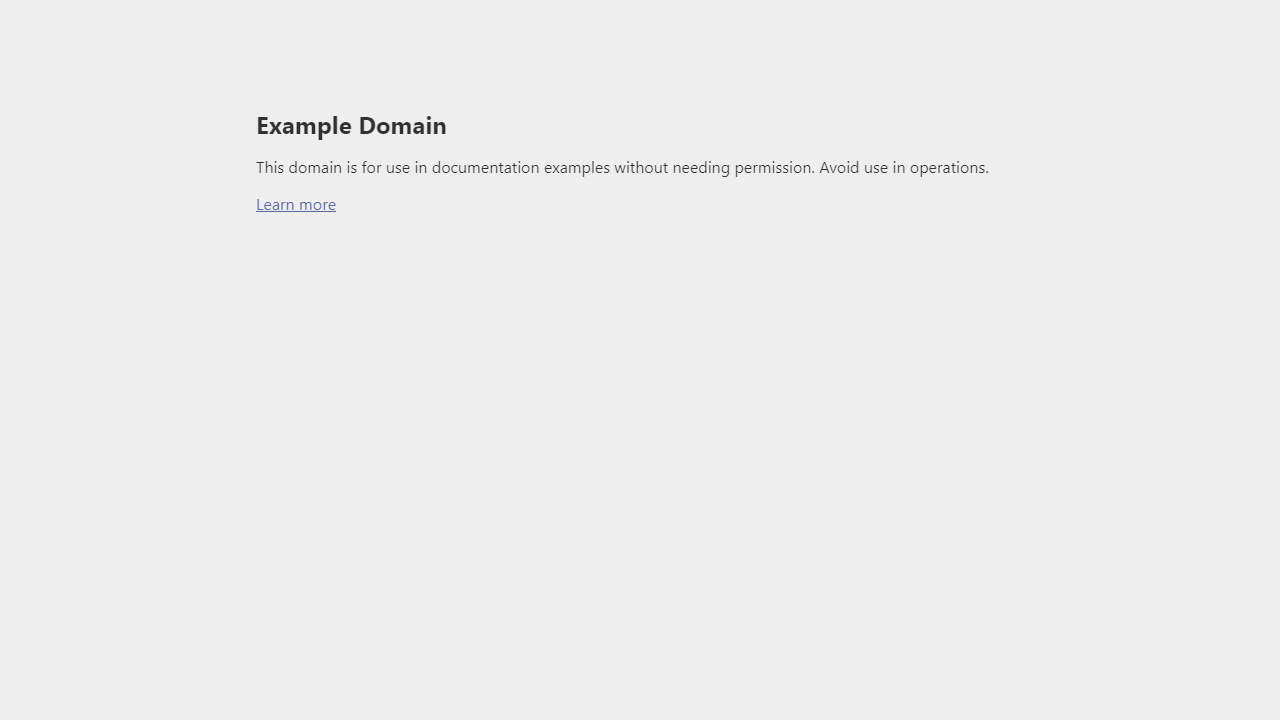

In [14]:
# The user issues a natural-language command
result = browser_faculty.user_browse("Navigate back to example.com")
print(f"NL command result: success={result.get('success')}")

if result.get('screenshot'):
    display(Image(filename=result['screenshot'], width=600))

## 6. Multi-Tab Browsing

The browser supports multiple tabs. This is useful when the agent needs to compare pages or keep a reference open.

In [15]:
# Open a second tab
browser_faculty.user_action("new_tab https://www.iana.org")

# List all open tabs
ctrl = browser_faculty._get_browser_controller()
tabs = ctrl.list_tabs()
for tab in tabs:
    prefix = "→" if tab["active"] else " "
    print(f"  {prefix} Tab {tab['index']}: {tab['title']} ({tab['url']})")

    Tab 0: Example Domain (https://example.com/)
  → Tab 1: Internet Assigned Numbers Authority (https://www.iana.org/)


In [16]:
# Switch back to the first tab
browser_faculty.user_action("switch_tab 0")

# Close the second tab
browser_faculty.user_action("close_tab 1")

{'success': True, 'active_tab': 0}

## 7. Authentication

The faculty supports several authentication strategies:

### Option A: Persistent browser profile
Pass `user_data_dir` to inherit cookies/sessions from your real browser profile:
```python
faculty = TinyWebBrowserFaculty(
    user_data_dir=r"C:\Users\<you>\AppData\Local\Microsoft\Edge\User Data"
)
```

### Option B: Manual login pause
The simulation pauses and asks you to log in manually:

In [17]:
# Uncomment to try manual login pause:
# browser_faculty.user_pause_for_login(
#     "https://login.microsoftonline.com",
#     message="Please log in with your Microsoft account."
# )

### Option C: Programmatic credential injection
```python
browser_faculty.user_inject_credentials(
    url="https://myapp.example.com/login",
    username="alice@example.com",
    password="s3cr3t",
)
```

### Option D: Save/restore session
After logging in once, save the session state for reuse:
```python
browser_faculty.user_save_session("my_session.json")
# ... later ...
browser_faculty.user_load_session("my_session.json")
```

## 8. Action Log

Every browser action is logged for inspection and debugging.

In [18]:
# View the action log
ctrl = browser_faculty._get_browser_controller()
log = ctrl.get_action_log()
print(f"Total actions logged: {len(log)}\n")
for entry in log[-5:]:  # show last 5
    status = "✓" if entry["success"] else "✗"
    print(f"  {status} {entry['timestamp'][:19]}  {entry['action']}  {entry.get('params', {})}")

Total actions logged: 27

  ✓ 2026-02-13T22:51:38  screenshot  {'full_page': False, 'path': 'C:\\Users\\pdasilva\\AppData\\Local\\Temp\\tinytroupe_browser_1771033897959.png'}
  ✓ 2026-02-13T22:51:38  execute_nl_command  {'command': 'Navigate back to example.com'}
  ✓ 2026-02-13T22:51:42  new_tab  {'url': 'https://www.iana.org'}
  ✓ 2026-02-13T22:51:42  switch_tab  {'index': 0}
  ✓ 2026-02-13T22:51:42  close_tab  {'index': 1}


## 9. Cleanup

Close the browser when done. The faculty can be reused — calling `ensure_browser()` or any user method will relaunch it.

In [19]:
browser_faculty.close_browser()
print("Browser closed.")

Browser closed.
